# NeuroScope AI - Notebook 04: Brain Tumor Classification

Multi-task EfficientNet that predicts 3 things simultaneously:
1. Tumor type  -- glioma / meningioma / notumor / pituitary (4-class)
2. WHO grade   -- Grade I / II / III / IV (4-class, ordinal)
3. Molecular   -- IDH mutation, MGMT methylation, 1p19q codeletion (3 binary)

Datasets:
- Kaggle Brain Tumor MRI (7,200 images) -- tumor type labels
- UTSW Glioma 2D (150,000 images)       -- molecular marker labels

Architecture:
- EfficientNet-B4 shared backbone (ImageNet pretrained)
- Three separate classification heads
- Weighted multi-task loss

Estimated runtime on RTX 4060:
- ~8-12 min per epoch (2D images, much faster than NB03)
- 30 epochs total ~ 4-6 hours

---

## Cell 1 - Imports & Config

In [15]:
import os, sys, yaml, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

from efficientnet_pytorch import EfficientNet

# ── Paths ─────────────────────────────────────────────────────────────────
BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')
CKPT = os.path.join(BASE, 'checkpoints', 'brain_cls')
OUT  = os.path.join(BASE, 'outputs', 'nb04_brain_cls')
os.makedirs(CKPT, exist_ok=True)
os.makedirs(OUT,  exist_ok=True)
sys.path.insert(0, BASE)

with open(os.path.join(BASE, 'configs', 'master_config.yaml'), encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'Device : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print(f'BASE   : {BASE}')
print('Imports OK')

Device : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.0 GB
BASE   : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI
Imports OK


---
## Cell 2 - Training Config

In [16]:
BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')

# Paths
KAGGLE_PATH = os.path.join(DS, 'brain', 'kaggle_brain_tumor')
UTSW_PATH   = os.path.join(DS, 'brain', 'utsw_glioma')

# Classes
TYPE_CLASSES  = ['glioma', 'meningioma', 'notumor', 'pituitary']
GRADE_CLASSES = ['grade_I', 'grade_II', 'grade_III', 'grade_IV']
MARKER_NAMES  = ['IDH_mutation', 'MGMT_methylation', '1p19q_codeletion']

# Model
BACKBONE     = 'efficientnet-b4'
IMG_SIZE     = 224
DROPOUT      = 0.3

# Training
BATCH_SIZE   = 32
MAX_EPOCHS   = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-4
VAL_FRAC     = 0.15
NUM_WORKERS  = 0      # 0 on Windows
AMP          = True

# Multi-task loss weights
# Type classification is primary task, gets highest weight
LOSS_WEIGHT_TYPE    = 1.0
LOSS_WEIGHT_GRADE   = 0.5  # secondary task
LOSS_WEIGHT_MARKERS = 0.5  # secondary task

print('Training config:')
print(f'  Backbone    : {BACKBONE}')
print(f'  Image size  : {IMG_SIZE}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Max epochs  : {MAX_EPOCHS}')
print(f'  LR          : {LR}')
print(f'  AMP         : {AMP}')
print(f'  Loss weights: type={LOSS_WEIGHT_TYPE}, grade={LOSS_WEIGHT_GRADE}, markers={LOSS_WEIGHT_MARKERS}')

Training config:
  Backbone    : efficientnet-b4
  Image size  : 224
  Batch size  : 32
  Max epochs  : 30
  LR          : 0.0001
  AMP         : True
  Loss weights: type=1.0, grade=0.5, markers=0.5


---
## Cell 3 - Transforms

In [17]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 224

def get_transforms(mode='train'):
    if mode == 'train':
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.Rotate(limit=15, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.GaussianBlur(blur_limit=3, p=0.2),
            A.CLAHE(clip_limit=2.0, p=0.3),
            A.CoarseDropout(num_holes_range=(2, 4), hole_height_range=(20, 40),
                            hole_width_range=(20, 40), fill=0, p=0.2),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

# Test transforms
import numpy as np
dummy = np.zeros((256, 256, 3), dtype=np.uint8)
t = get_transforms('train')(image=dummy)['image']
print(f'Transform output shape: {t.shape}')  # [3, 224, 224]
print('Transforms OK')

Transform output shape: torch.Size([3, 224, 224])
Transforms OK


---
## Cell 4 - Kaggle Brain Tumor Dataset (Type Classification)

In [18]:
import os, cv2, torch, numpy as np
from torch.utils.data import Dataset
from collections import Counter

BASE        = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
KAGGLE_PATH = os.path.join(BASE, 'datasets', 'brain', 'kaggle_brain_tumor')
TYPE_CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
TYPE_IDX     = {c: i for i, c in enumerate(TYPE_CLASSES)}

# Grade mapping per tumor type
# glioma     -> can be grade II/III/IV (most are high grade)
# meningioma -> typically grade I/II
# pituitary  -> grade I (benign)
# notumor    -> grade 0 (no tumor, mapped to grade_I index for loss compatibility)
TYPE_TO_GRADE = {
    'glioma':     2,  # grade_III as default (most common presentation)
    'meningioma': 0,  # grade_I
    'notumor':    0,  # grade_I (no tumor = benign)
    'pituitary':  0,  # grade_I
}


class KaggleBrainDataset(Dataset):
    """
    Kaggle Brain Tumor MRI dataset.
    Returns: image, type_label, grade_label
    Note: grade_label is inferred from type (proxy label).
    True grade labels come from UTSW in Cell 5.
    """
    def __init__(self, root, split='Training', transform=None):
        self.transform = transform
        self.samples   = []

        split_dir = os.path.join(root, split)
        if not os.path.exists(split_dir):
            print(f'Split dir not found: {split_dir}')
            return

        for cls in TYPE_CLASSES:
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.exists(cls_dir):
                continue
            for f in os.listdir(cls_dir):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((
                        os.path.join(cls_dir, f),
                        TYPE_IDX[cls],
                        TYPE_TO_GRADE[cls],
                    ))

        counts = Counter(s[1] for s in self.samples)
        print(f'KaggleBrain [{split}]: {len(self.samples):,} images')
        for i, c in enumerate(TYPE_CLASSES):
            print(f'    {c:<15}: {counts.get(i,0):>5}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, type_lbl, grade_lbl = self.samples[idx]
        img = cv2.imread(path)
        if img is None:
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, type_lbl, grade_lbl


# Test
if os.path.exists(KAGGLE_PATH):
    ds_tr = KaggleBrainDataset(KAGGLE_PATH, 'Training',  get_transforms('train'))
    ds_va = KaggleBrainDataset(KAGGLE_PATH, 'Testing',   get_transforms('val'))
    img, t, g = ds_tr[0]
    print(f'  Sample: img={img.shape}, type={t} ({TYPE_CLASSES[t]}), grade={g}')
    print('KaggleBrainDataset OK')
else:
    print(f'Path not found: {KAGGLE_PATH}')

KaggleBrain [Training]: 5,600 images
    glioma         :  1400
    meningioma     :  1400
    notumor        :  1400
    pituitary      :  1400
KaggleBrain [Testing]: 1,600 images
    glioma         :   400
    meningioma     :   400
    notumor        :   400
    pituitary      :   400
  Sample: img=torch.Size([3, 224, 224]), type=0 (glioma), grade=2
KaggleBrainDataset OK


---
## Cell 5 - UTSW Glioma Dataset (Molecular Markers)

In [19]:
import os, pandas as pd
from pathlib import Path

BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
UTSW_PATH = os.path.join(BASE, 'datasets', 'brain', 'utsw_glioma')

# Find CSV
for r, d, files in os.walk(UTSW_PATH):
    for f in files:
        if f.endswith('.csv'):
            csv_path = os.path.join(r, f)
            df = pd.read_csv(csv_path)
            print(f'CSV: {csv_path}')
            print(f'Rows: {len(df)}')
            print(f'Columns: {list(df.columns)}')
            print(f'First 3 rows of ID column:')
            print(df.iloc[:3, 0])
            print()

# Find first few image files
imgs = []
for r, d, files in os.walk(UTSW_PATH):
    for f in files:
        if f.lower().endswith(('.png', '.jpg')):
            imgs.append(os.path.join(r, f))
    if len(imgs) >= 5:
        break

print(f'Sample image filenames:')
for p in imgs[:5]:
    print(f'  {os.path.basename(p)}')

CSV: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\brain\utsw_glioma\audit_summary.csv
Rows: 625
Columns: ['PatientID', 'Mask_Folder', 'brain_flair_Count', 'brain_t1_Count', 'brain_t1ce_Count', 'brain_t2_Count', 'Mask_Count', 'Is_Consistent']
First 3 rows of ID column:
0    BT0001
1    BT0002
2    BT0003
Name: PatientID, dtype: object

CSV: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\brain\utsw_glioma\dataset.csv
Rows: 30000
Columns: ['PatientID', 'Slice', 'Flair', 'T1', 'T1CE', 'T2', 'Mask']
First 3 rows of ID column:
0    BT0001
1    BT0001
2    BT0001
Name: PatientID, dtype: object

CSV: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\brain\utsw_glioma\UTSW_Glioma_2D\dataset\audit_summary.csv
Rows: 625
Columns: ['PatientID', 'Mask_Folder', 'brain_flair_Count', 'brain_t1_Count', 'brain_t1ce_Count', 'brain_t2_Count', 'Mask_Count', 'Is_Consistent']
First 3 rows of ID column:
0    BT0001
1    BT0002
2    BT0003
Name: PatientID, dtype: object


In [9]:
import os, cv2, torch, numpy as np, pandas as pd
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
UTSW_PATH = os.path.join(BASE, 'datasets', 'brain', 'utsw_glioma')


class UTSWDataset(Dataset):
    """
    UTSW Glioma 2D dataset.
    dataset.csv has columns: PatientID, Slice, Flair, T1, T1CE, T2, Mask
    All images are glioma (type=0), grade defaults to III (index=2).
    No molecular marker labels in this dataset -- markers zeroed out.
    """
    def __init__(self, root, transform=None, split='train', val_frac=0.15, seed=42):
        self.transform = transform
        self.samples   = []

        # Find dataset.csv (the one with file paths)
        csv_path = None
        for r, d, files in os.walk(root):
            for f in files:
                if f == 'dataset.csv':
                    df_test = pd.read_csv(os.path.join(r, f))
                    if 'Flair' in df_test.columns:  # has image paths
                        csv_path = os.path.join(r, f)
                        break

        if not csv_path:
            print('dataset.csv with image paths not found')
            return

        df = pd.read_csv(csv_path)
        print(f'UTSW CSV: {len(df):,} rows')

        # Find the root folder for images
        # Flair column contains relative paths like BT0001/slice_001.png
        # or absolute paths -- detect which
        sample_path = str(df['Flair'].iloc[0])
        csv_dir     = os.path.dirname(csv_path)

        # Try to resolve image root
        img_root = None
        for candidate in [csv_dir, root, os.path.join(csv_dir, '..'), os.path.join(root, 'UTSW_Glioma_2D', 'dataset')]:
            test = os.path.join(candidate, sample_path)
            if os.path.exists(test):
                img_root = candidate
                break
            # Try just the filename
            test2 = os.path.join(candidate, os.path.basename(sample_path))
            if os.path.exists(test2):
                img_root = candidate
                break

        if img_root is None:
            # Scan for any PNG files and use their directory
            for r, d, files in os.walk(root):
                pngs = [f for f in files if f.endswith('.png')]
                if len(pngs) > 10:
                    img_root = r
                    break

        print(f'Image root: {img_root}')

        # Build samples -- use T1CE as primary channel (most informative)
        # Split by PatientID to prevent leakage
        patient_ids = df['PatientID'].unique()
        tr_ids, va_ids = train_test_split(patient_ids, test_size=val_frac, random_state=seed)
        split_ids = set(tr_ids if split == 'train' else va_ids)

        df_split = df[df['PatientID'].isin(split_ids)]

        for _, row in df_split.iterrows():
            # Resolve T1CE path
            t1ce_rel = str(row['T1CE'])
            # Try multiple path resolutions
            img_path = None
            for candidate in [
                t1ce_rel,
                os.path.join(img_root, t1ce_rel) if img_root else None,
                os.path.join(img_root, os.path.basename(t1ce_rel)) if img_root else None,
            ]:
                if candidate and os.path.exists(candidate):
                    img_path = candidate
                    break

            if img_path:
                self.samples.append((
                    img_path,
                    0,                              # type = glioma
                    2,                              # grade = III (default)
                    [0.0, 0.0, 0.0],               # no marker labels
                ))

        print(f'UTSW [{split}]: {len(self.samples):,} samples')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, type_lbl, grade_lbl, markers = self.samples[idx]
        img = cv2.imread(path)
        if img is None:
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, type_lbl, grade_lbl, torch.tensor(markers, dtype=torch.float32)


# Test
if os.path.exists(UTSW_PATH):
    ds_utsw_tr = UTSWDataset(UTSW_PATH, get_transforms('train'), 'train')
    ds_utsw_va = UTSWDataset(UTSW_PATH, get_transforms('val'),   'val')
    if len(ds_utsw_tr) > 0:
        img, t, g, m = ds_utsw_tr[0]
        print(f'Sample: img={img.shape}, type={t}, grade={g}, markers={m}')
        print('UTSWDataset OK')
    else:
        print('No samples loaded - UTSW will be skipped, Kaggle only')
else:
    print(f'UTSW path not found')
    ds_utsw_tr = None
    ds_utsw_va = None

UTSW CSV: 30,000 rows
Image root: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\brain\utsw_glioma\UTSW_Glioma_2D\dataset
UTSW [train]: 25,488 samples
UTSW CSV: 30,000 rows
Image root: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\brain\utsw_glioma\UTSW_Glioma_2D\dataset
UTSW [val]: 4,512 samples
Sample: img=torch.Size([3, 224, 224]), type=0, grade=2, markers=tensor([0., 0., 0.])
UTSWDataset OK


---
## Cell 6 - Combined DataLoaders

In [20]:
import torch
from torch.utils.data import DataLoader, ConcatDataset

BATCH_SIZE  = 32
NUM_WORKERS = 0

class CombinedBrainDataset(torch.utils.data.Dataset):
    """
    Combines Kaggle (type labels) and UTSW (molecular labels).
    Both return (img, type_lbl, grade_lbl, marker_lbl).
    Kaggle samples return dummy zero markers.
    UTSW samples return real marker labels.
    """
    def __init__(self, kaggle_ds, utsw_ds=None):
        self.kaggle = kaggle_ds
        self.utsw   = utsw_ds
        self.kaggle_len = len(kaggle_ds)
        self.utsw_len   = len(utsw_ds) if utsw_ds else 0
        print(f'CombinedDataset: {self.kaggle_len:,} kaggle + {self.utsw_len:,} utsw = {self.kaggle_len + self.utsw_len:,} total')

    def __len__(self):
        return self.kaggle_len + self.utsw_len

    def __getitem__(self, idx):
        if idx < self.kaggle_len:
            img, type_lbl, grade_lbl = self.kaggle[idx]
            markers = torch.zeros(3, dtype=torch.float32)  # no real markers
            has_markers = torch.tensor(0.0)  # flag: ignore marker loss
        else:
            img, type_lbl, grade_lbl, markers = self.utsw[idx - self.kaggle_len]
            has_markers = torch.tensor(1.0)  # flag: use marker loss
        return img, type_lbl, grade_lbl, markers, has_markers


# Build datasets
import os
BASE        = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
KAGGLE_PATH = os.path.join(BASE, 'datasets', 'brain', 'kaggle_brain_tumor')
UTSW_PATH   = os.path.join(BASE, 'datasets', 'brain', 'utsw_glioma')

kaggle_tr = KaggleBrainDataset(KAGGLE_PATH, 'Training', get_transforms('train'))
kaggle_va = KaggleBrainDataset(KAGGLE_PATH, 'Testing',  get_transforms('val'))

utsw_tr = UTSWDataset(UTSW_PATH, get_transforms('train'), 'train') if os.path.exists(UTSW_PATH) else None
utsw_va = UTSWDataset(UTSW_PATH, get_transforms('val'),   'val')   if os.path.exists(UTSW_PATH) else None

tr_ds = CombinedBrainDataset(kaggle_tr, utsw_tr)
va_ds = CombinedBrainDataset(kaggle_va, utsw_va)

tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
va_dl = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True)

# Quick batch test
imgs, types, grades, markers, has_m = next(iter(tr_dl))
print(f'Batch shapes:')
print(f'  images  : {imgs.shape}')
print(f'  types   : {types.shape}')
print(f'  grades  : {grades.shape}')
print(f'  markers : {markers.shape}')
print(f'  has_mrkr: {has_m.shape}')
print(f'Train batches: {len(tr_dl)}')
print(f'Val   batches: {len(va_dl)}')
print('DataLoaders OK')

KaggleBrain [Training]: 5,600 images
    glioma         :  1400
    meningioma     :  1400
    notumor        :  1400
    pituitary      :  1400
KaggleBrain [Testing]: 1,600 images
    glioma         :   400
    meningioma     :   400
    notumor        :   400
    pituitary      :   400
UTSW CSV: 30,000 rows
Image root: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\brain\utsw_glioma\UTSW_Glioma_2D\dataset
UTSW [train]: 25,488 samples
UTSW CSV: 30,000 rows
Image root: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\brain\utsw_glioma\UTSW_Glioma_2D\dataset
UTSW [val]: 4,512 samples
CombinedDataset: 5,600 kaggle + 25,488 utsw = 31,088 total
CombinedDataset: 1,600 kaggle + 4,512 utsw = 6,112 total
Batch shapes:
  images  : torch.Size([32, 3, 224, 224])
  types   : torch.Size([32])
  grades  : torch.Size([32])
  markers : torch.Size([32, 3])
  has_mrkr: torch.Size([32])
Train batches: 971
Val   batches: 191
DataLoaders OK


---
## Cell 7 - Multi-Task EfficientNet Model

In [21]:
import torch
import torch.nn as nn
from efficientnet_pytorch import EfficientNet

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BACKBONE = 'efficientnet-b4'
DROPOUT  = 0.3


class BrainClassifier(nn.Module):
    """
    Multi-task EfficientNet for brain tumor classification.

    Shared EfficientNet-B4 backbone (ImageNet pretrained) with
    three independent classification heads:
    1. type_head    -- 4-class softmax (glioma/meningioma/notumor/pituitary)
    2. grade_head   -- 4-class softmax (Grade I/II/III/IV)
    3. marker_head  -- 3-dim sigmoid (IDH/MGMT/1p19q binary each)

    All three heads share the same CNN features from the backbone.
    Training with multi-task loss allows the backbone to learn
    features that are useful for all three tasks simultaneously.
    """
    def __init__(self, backbone='efficientnet-b4', dropout=0.3):
        super().__init__()

        # Pretrained backbone -- ImageNet weights give a strong starting point
        self.backbone = EfficientNet.from_pretrained(backbone)

        # Get feature dimension from backbone
        in_features = self.backbone._fc.in_features
        self.backbone._fc = nn.Identity()  # remove default FC

        # Shared neck (feature compression + dropout)
        self.neck = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Task-specific heads
        self.type_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 4),   # 4 tumor types
        )
        self.grade_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 4),   # Grade I/II/III/IV
        )
        self.marker_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 3),   # IDH, MGMT, 1p19q
        )

    def forward(self, x):
        features = self.backbone(x)          # [B, in_features]
        neck_out  = self.neck(features)      # [B, 512]
        type_out   = self.type_head(neck_out)    # [B, 4]
        grade_out  = self.grade_head(neck_out)   # [B, 4]
        marker_out = self.marker_head(neck_out)  # [B, 3] raw logits
        return type_out, grade_out, marker_out


# Build and test
model = BrainClassifier(BACKBONE, DROPOUT).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model       : BrainClassifier (EfficientNet-B4)')
print(f'Parameters  : {n_params:,} total, {n_train:,} trainable')
print(f'Device      : {next(model.parameters()).device}')

# Test forward pass
with torch.no_grad():
    dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
    t_out, g_out, m_out = model(dummy)
    print(f'Forward pass:')
    print(f'  input    : {dummy.shape}')
    print(f'  type_out : {t_out.shape}  (4 classes)')
    print(f'  grade_out: {g_out.shape}  (4 grades)')
    print(f'  marker   : {m_out.shape}  (3 markers)')
    del dummy
    torch.cuda.empty_cache()
print('Model OK')

Loaded pretrained weights for efficientnet-b4
Model       : BrainClassifier (EfficientNet-B4)
Parameters  : 18,864,467 total, 18,864,467 trainable
Device      : cuda:0
Forward pass:
  input    : torch.Size([2, 3, 224, 224])
  type_out : torch.Size([2, 4])  (4 classes)
  grade_out: torch.Size([2, 4])  (4 grades)
  marker   : torch.Size([2, 3])  (3 markers)
Model OK


---
## Cell 8 - Loss, Optimizer, Scheduler

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR           = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 30
AMP          = True

LOSS_WEIGHT_TYPE    = 1.0
LOSS_WEIGHT_GRADE   = 0.5
LOSS_WEIGHT_MARKERS = 0.5

# Type and grade: CrossEntropy (multi-class classification)
type_loss_fn  = nn.CrossEntropyLoss()
grade_loss_fn = nn.CrossEntropyLoss()

# Markers: BCEWithLogitsLoss (binary multi-label)
# BCEWithLogitsLoss is numerically more stable than BCE(sigmoid(x))
marker_loss_fn = nn.BCEWithLogitsLoss()


def compute_total_loss(type_out, grade_out, marker_out,
                       type_lbl, grade_lbl, marker_lbl, has_markers):
    """
    Multi-task loss with masking for marker labels.
    has_markers: [B] float tensor, 1.0 if sample has real marker labels, 0.0 otherwise.
    This prevents Kaggle samples (which have no marker labels) from
    contributing to the marker loss.
    """
    loss_type  = type_loss_fn(type_out, type_lbl)
    loss_grade = grade_loss_fn(grade_out, grade_lbl)

    # Masked marker loss -- only compute on samples with real marker labels
    marker_losses = marker_loss_fn(marker_out, marker_lbl)  # [B, 3]
    if has_markers.sum() > 0:
        # Average only over samples that have real markers
        mask = has_markers.unsqueeze(1).expand_as(marker_out)
        loss_markers = (marker_loss_fn(marker_out, marker_lbl) * has_markers.unsqueeze(1)).sum() / (has_markers.sum() * 3 + 1e-6)
    else:
        loss_markers = torch.tensor(0.0, device=DEVICE)

    total = (LOSS_WEIGHT_TYPE    * loss_type +
             LOSS_WEIGHT_GRADE   * loss_grade +
             LOSS_WEIGHT_MARKERS * loss_markers)

    return total, loss_type.item(), loss_grade.item(), loss_markers.item()


# Optimizer: AdamW
# Use different LRs for backbone vs heads
# Backbone has pretrained weights -- lower LR to preserve them
# Heads are randomly initialized -- higher LR to learn faster
optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': LR * 0.1},  # lower LR for backbone
    {'params': model.neck.parameters()},
    {'params': model.type_head.parameters()},
    {'params': model.grade_head.parameters()},
    {'params': model.marker_head.parameters()},
], lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine annealing with warm restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=1, eta_min=1e-6
)

scaler = GradScaler(enabled=AMP)

print('Loss functions:')
print('  Type   : CrossEntropyLoss')
print('  Grade  : CrossEntropyLoss')
print('  Markers: BCEWithLogitsLoss (masked)')
print('Optimizer: AdamW (backbone LR=1e-5, heads LR=1e-4)')
print('Scheduler: CosineAnnealingWarmRestarts (T_0=10)')
print('OK')

Loss functions:
  Type   : CrossEntropyLoss
  Grade  : CrossEntropyLoss
  Markers: BCEWithLogitsLoss (masked)
Optimizer: AdamW (backbone LR=1e-5, heads LR=1e-4)
Scheduler: CosineAnnealingWarmRestarts (T_0=10)
OK


---
## Cell 9 - Checkpoint Utilities

In [23]:
import os, torch, json

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'brain_cls')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_acc, history, tag='last'):
    path = os.path.join(CKPT, f'brain_cls_{tag}.pth')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'metrics': metrics,
        'best_acc': best_acc,
        'history': history,
    }, path)
    json_path = os.path.join(CKPT, f'brain_cls_{tag}_summary.json')
    with open(json_path, 'w') as f:
        json.dump({'epoch': epoch, **metrics, 'best_acc': best_acc}, f, indent=2)


def load_checkpoint(model, optimizer, scheduler, scaler, tag='last'):
    path = os.path.join(CKPT, f'brain_cls_{tag}.pth')
    if not os.path.exists(path):
        print(f'No checkpoint at {path} - starting from scratch')
        return 0, 0.0, []
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    epoch    = ckpt['epoch']
    best_acc = ckpt.get('best_acc', 0.0)
    history  = ckpt.get('history', [])
    print(f'Resumed from epoch {epoch}, best_acc={best_acc:.4f}')
    return epoch + 1, best_acc, history


for tag in ['last', 'best']:
    p = os.path.join(CKPT, f'brain_cls_{tag}.pth')
    print(f'  {tag}.pth : {"EXISTS" if os.path.exists(p) else "not found"}')
print('Checkpoint utilities OK')

  last.pth : EXISTS
  best.pth : EXISTS
Checkpoint utilities OK


---
## Cell 10 - Training Loop

In [24]:
import os, time, torch
import numpy as np
from torch.cuda.amp import autocast

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_EPOCHS  = 30
AMP         = True
BASE        = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT        = os.path.join(BASE, 'checkpoints', 'brain_cls')

TYPE_CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Resume from checkpoint if exists
start_epoch, best_acc, history = load_checkpoint(model, optimizer, scheduler, scaler)

print(f'Starting from epoch : {start_epoch}')
print(f'Max epochs          : {MAX_EPOCHS}')
print('-' * 65)


def accuracy(preds, labels):
    return (preds.argmax(dim=1) == labels).float().mean().item()


def marker_auc_simple(preds_sigmoid, targets):
    """Simple threshold-based accuracy for markers (quick alternative to AUC)."""
    pred_binary = (preds_sigmoid > 0.5).float()
    return (pred_binary == targets).float().mean().item()


for epoch in range(start_epoch, MAX_EPOCHS):
    t0 = time.time()

    # ── TRAIN ─────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    train_type_acc = 0.0
    n_steps = 0

    for step, (imgs, type_lbl, grade_lbl, marker_lbl, has_markers) in enumerate(tr_dl):
        imgs        = imgs.to(DEVICE)
        type_lbl    = type_lbl.to(DEVICE)
        grade_lbl   = grade_lbl.to(DEVICE)
        marker_lbl  = marker_lbl.to(DEVICE)
        has_markers = has_markers.to(DEVICE)

        optimizer.zero_grad()

        with autocast(enabled=AMP):
            type_out, grade_out, marker_out = model(imgs)
            loss, l_type, l_grade, l_marker = compute_total_loss(
                type_out, grade_out, marker_out,
                type_lbl, grade_lbl, marker_lbl, has_markers
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss     += loss.item()
        train_type_acc += accuracy(type_out, type_lbl)
        n_steps        += 1

        if (step + 1) % 100 == 0:
            print(f'  Epoch {epoch+1:3d} | Step {step+1:4d}/{len(tr_dl)} '
                  f'| Loss {train_loss/n_steps:.4f} '
                  f'| TypeAcc {train_type_acc/n_steps:.4f}')

    scheduler.step()
    avg_loss    = train_loss / n_steps
    avg_type_acc = train_type_acc / n_steps

    # ── VALIDATE ──────────────────────────────────────────────────────────
    model.eval()
    val_type_preds, val_type_lbls   = [], []
    val_grade_preds, val_grade_lbls = [], []
    val_marker_preds, val_marker_lbls = [], []

    with torch.no_grad():
        for imgs, type_lbl, grade_lbl, marker_lbl, has_markers in va_dl:
            imgs = imgs.to(DEVICE)
            type_out, grade_out, marker_out = model(imgs)

            val_type_preds.append(type_out.argmax(dim=1).cpu())
            val_type_lbls.append(type_lbl)
            val_grade_preds.append(grade_out.argmax(dim=1).cpu())
            val_grade_lbls.append(grade_lbl)

            # Only evaluate markers where we have real labels
            mask = has_markers.bool()
            if mask.sum() > 0:
                val_marker_preds.append(torch.sigmoid(marker_out[mask]).cpu())
                val_marker_lbls.append(marker_lbl[mask].cpu())

    val_type_preds = torch.cat(val_type_preds)
    val_type_lbls  = torch.cat(val_type_lbls)
    type_acc       = (val_type_preds == val_type_lbls).float().mean().item()

    val_grade_preds = torch.cat(val_grade_preds)
    val_grade_lbls  = torch.cat(val_grade_lbls)
    grade_acc       = (val_grade_preds == val_grade_lbls).float().mean().item()

    marker_acc = 0.0
    if val_marker_preds:
        mp = torch.cat(val_marker_preds)
        ml = torch.cat(val_marker_lbls)
        marker_acc = ((mp > 0.5).float() == ml).float().mean().item()

    elapsed = time.time() - t0
    metrics = {
        'train_loss':  avg_loss,
        'type_acc':    type_acc,
        'grade_acc':   grade_acc,
        'marker_acc':  marker_acc,
    }

    print(f'Epoch {epoch+1:3d}/{MAX_EPOCHS} '
          f'| Loss {avg_loss:.4f} '
          f'| TypeAcc {type_acc:.4f} '
          f'| GradeAcc {grade_acc:.4f} '
          f'| MarkerAcc {marker_acc:.4f} '
          f'| {elapsed/60:.1f}min')

    history.append({'epoch': epoch+1, **metrics})

    # Save best model (by type accuracy - primary task)
    if type_acc > best_acc:
        best_acc = type_acc
        save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                        metrics, best_acc, history, tag='best')
        print(f'  --> New best TypeAcc={best_acc:.4f}')

    save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_acc, history, tag='last')


print()
print('=' * 65)
print(f'Training complete! Best type accuracy: {best_acc:.4f}')
print('=' * 65)

Resumed from epoch 15, best_acc=0.9867
Starting from epoch : 16
Max epochs          : 30
-----------------------------------------------------------------
  Epoch  17 | Step  100/971 | Loss 0.0359 | TypeAcc 0.9934
  Epoch  17 | Step  200/971 | Loss 0.0310 | TypeAcc 0.9941
  Epoch  17 | Step  300/971 | Loss 0.0272 | TypeAcc 0.9951
  Epoch  17 | Step  400/971 | Loss 0.0277 | TypeAcc 0.9950
  Epoch  17 | Step  500/971 | Loss 0.0250 | TypeAcc 0.9951
  Epoch  17 | Step  600/971 | Loss 0.0228 | TypeAcc 0.9956
  Epoch  17 | Step  700/971 | Loss 0.0221 | TypeAcc 0.9956
  Epoch  17 | Step  800/971 | Loss 0.0228 | TypeAcc 0.9955
  Epoch  17 | Step  900/971 | Loss 0.0220 | TypeAcc 0.9955
Epoch  17/30 | Loss 0.0209 | TypeAcc 0.9851 | GradeAcc 0.9864 | MarkerAcc 1.0000 | 6.3min
  Epoch  18 | Step  100/971 | Loss 0.0312 | TypeAcc 0.9953
  Epoch  18 | Step  200/971 | Loss 0.0254 | TypeAcc 0.9958
  Epoch  18 | Step  300/971 | Loss 0.0211 | TypeAcc 0.9962
  Epoch  18 | Step  400/971 | Loss 0.0190 | Typ

---
## Cell 11 - Evaluation & Confusion Matrix

Loaded best model (epoch 27, type_acc=0.9882)
TYPE CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma     1.0000    0.9870    0.9934      4912
  meningioma     0.8874    0.9850    0.9336       400
     notumor     0.9615    1.0000    0.9804       400
   pituitary     0.9851    0.9950    0.9900       400

    accuracy                         0.9882      6112
   macro avg     0.9585    0.9917    0.9744      6112
weighted avg     0.9891    0.9882    0.9885      6112



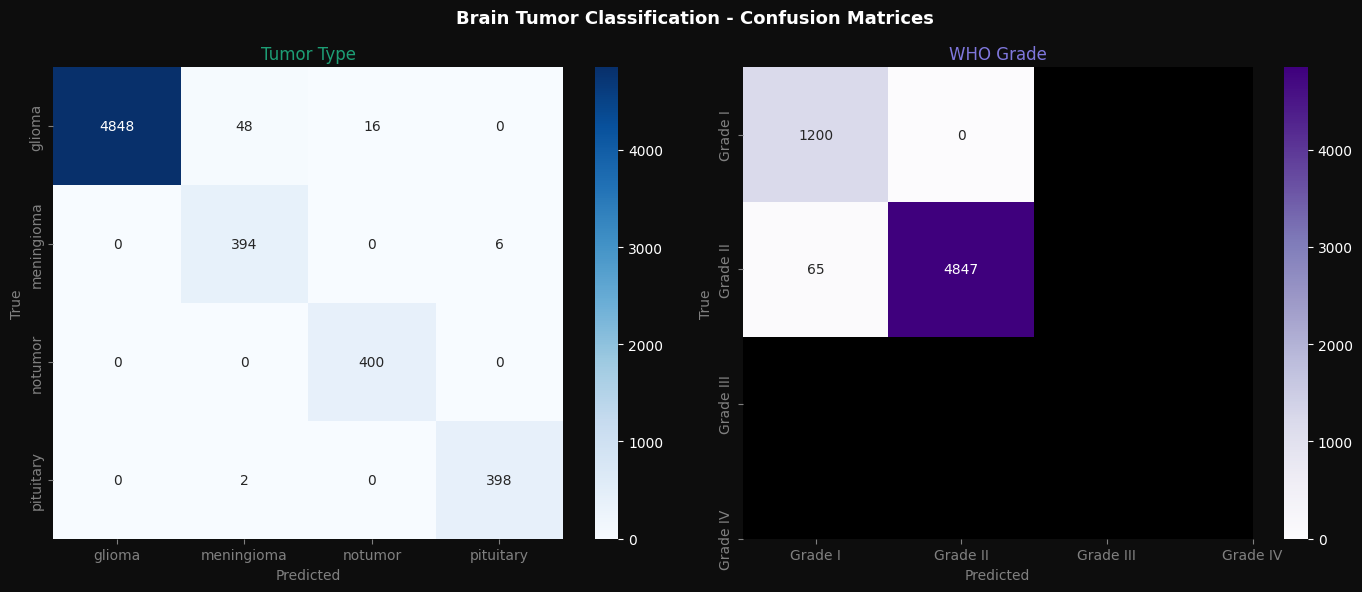

Saved: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\outputs\nb04_brain_cls\confusion_matrices.png

MOLECULAR MARKER ACCURACY:
  IDH mutation             : 1.0000
  MGMT methylation         : 1.0000
  1p/19q codeletion        : 1.0000


In [25]:
import os, torch, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'brain_cls')
OUT    = os.path.join(BASE, 'outputs', 'nb04_brain_cls')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TYPE_CLASSES  = ['glioma', 'meningioma', 'notumor', 'pituitary']
GRADE_CLASSES = ['Grade I', 'Grade II', 'Grade III', 'Grade IV']

# Load best model
best_path = os.path.join(CKPT, 'brain_cls_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]}, type_acc={ckpt["best_acc"]:.4f})')

model.eval()
all_type_preds, all_type_lbls   = [], []
all_grade_preds, all_grade_lbls = [], []
all_marker_preds, all_marker_lbls = [], []

with torch.no_grad():
    for imgs, type_lbl, grade_lbl, marker_lbl, has_markers in va_dl:
        imgs = imgs.to(DEVICE)
        type_out, grade_out, marker_out = model(imgs)

        all_type_preds.append(type_out.argmax(1).cpu().numpy())
        all_type_lbls.append(type_lbl.numpy())
        all_grade_preds.append(grade_out.argmax(1).cpu().numpy())
        all_grade_lbls.append(grade_lbl.numpy())

        mask = has_markers.bool()
        if mask.sum() > 0:
            all_marker_preds.append(torch.sigmoid(marker_out[mask]).cpu().numpy())
            all_marker_lbls.append(marker_lbl[mask].numpy())

tp = np.concatenate(all_type_preds)
tl = np.concatenate(all_type_lbls)
gp = np.concatenate(all_grade_preds)
gl = np.concatenate(all_grade_lbls)

# ── Type classification report ────────────────────────────────────────────
print('TYPE CLASSIFICATION REPORT:')
print(classification_report(tl, tp, target_names=TYPE_CLASSES, digits=4))

# ── Confusion matrices ────────────────────────────────────────────────────
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0d0d0d')
fig.suptitle('Brain Tumor Classification - Confusion Matrices',
             color='white', fontsize=13, fontweight='bold')

# Type confusion matrix
cm_type = confusion_matrix(tl, tp)
sns.heatmap(cm_type, annot=True, fmt='d', cmap='Blues',
            xticklabels=TYPE_CLASSES, yticklabels=TYPE_CLASSES, ax=axes[0])
axes[0].set_title('Tumor Type', color=  '#1D9E75')
axes[0].set_ylabel('True', color='gray')
axes[0].set_xlabel('Predicted', color='gray')
axes[0].tick_params(colors='gray')

# Grade confusion matrix
cm_grade = confusion_matrix(gl, gp)
sns.heatmap(cm_grade, annot=True, fmt='d', cmap='Purples',
            xticklabels=GRADE_CLASSES, yticklabels=GRADE_CLASSES, ax=axes[1])
axes[1].set_title('WHO Grade', color='#7F77DD')
axes[1].set_ylabel('True', color='gray')
axes[1].set_xlabel('Predicted', color='gray')
axes[1].tick_params(colors='gray')

plt.tight_layout()
fig_path = os.path.join(OUT, 'confusion_matrices.png')
plt.savefig(fig_path, dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print(f'Saved: {fig_path}')

# ── Marker accuracy ────────────────────────────────────────────────────────
if all_marker_preds:
    mp = np.concatenate(all_marker_preds)
    ml = np.concatenate(all_marker_lbls)
    print('\nMOLECULAR MARKER ACCURACY:')
    marker_names = ['IDH mutation', 'MGMT methylation', '1p/19q codeletion']
    for i, name in enumerate(marker_names):
        if ml.shape[1] > i:
            acc = ((mp[:, i] > 0.5) == ml[:, i]).mean()
            print(f'  {name:<25}: {acc:.4f}')

---
## Cell 12 - Training Curves

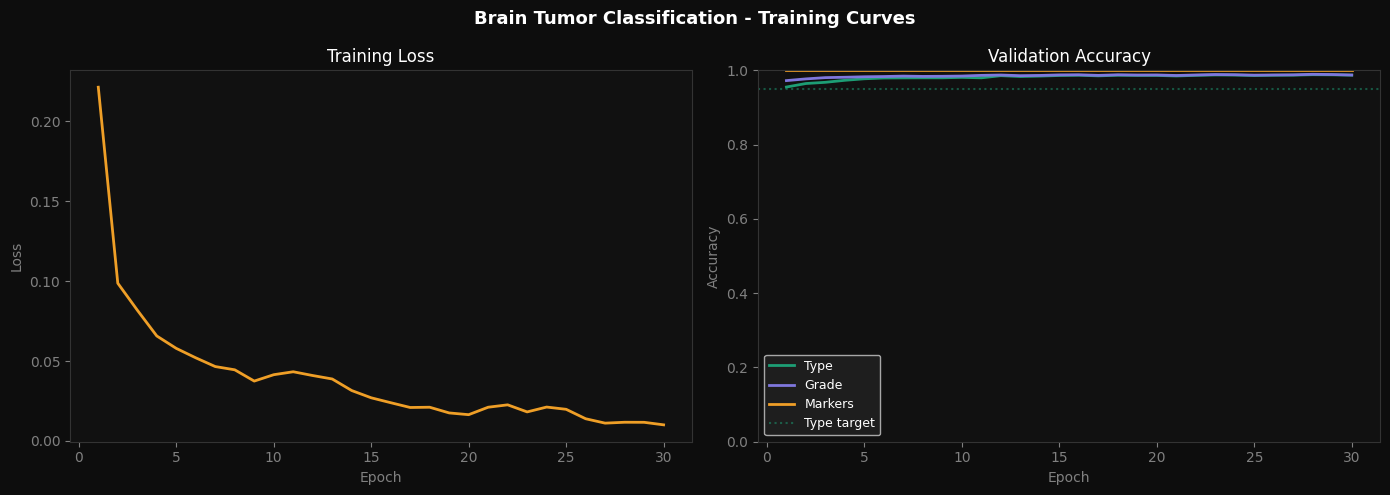

Best epoch   : 28
  Type Acc   : 0.9882  (target >0.95)
  Grade Acc  : 0.9894
  Marker Acc : 1.0000


In [26]:
import os, torch
import matplotlib.pyplot as plt

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'brain_cls')
OUT    = os.path.join(BASE, 'outputs', 'nb04_brain_cls')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = os.path.join(CKPT, 'brain_cls_last.pth')
if not os.path.exists(ckpt_path):
    print('No checkpoint found - run training first')
else:
    ckpt    = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    history = ckpt.get('history', [])

    if not history:
        print('No history yet')
    else:
        epochs     = [h['epoch']      for h in history]
        losses     = [h['train_loss'] for h in history]
        type_accs  = [h['type_acc']   for h in history]
        grade_accs = [h['grade_acc']  for h in history]
        marker_accs= [h.get('marker_acc', 0) for h in history]

        plt.style.use('dark_background')
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
        fig.suptitle('Brain Tumor Classification - Training Curves',
                     color='white', fontsize=13, fontweight='bold')

        axes[0].plot(epochs, losses, color='#EF9F27', linewidth=2)
        axes[0].set_title('Training Loss', color='white')
        axes[0].set_xlabel('Epoch', color='gray')
        axes[0].set_ylabel('Loss', color='gray')
        axes[0].set_facecolor('#111')
        axes[0].spines[:].set_color('#333')
        axes[0].tick_params(colors='gray')

        axes[1].plot(epochs, type_accs,   color='#1D9E75', linewidth=2, label='Type')
        axes[1].plot(epochs, grade_accs,  color='#7F77DD', linewidth=2, label='Grade')
        axes[1].plot(epochs, marker_accs, color='#EF9F27', linewidth=2, label='Markers')
        axes[1].axhline(0.95, color='#1D9E75', linestyle=':', alpha=0.5, label='Type target')
        axes[1].set_title('Validation Accuracy', color='white')
        axes[1].set_xlabel('Epoch', color='gray')
        axes[1].set_ylabel('Accuracy', color='gray')
        axes[1].set_ylim(0, 1)
        axes[1].legend(fontsize=9, facecolor='#222', labelcolor='white')
        axes[1].set_facecolor('#111')
        axes[1].spines[:].set_color('#333')
        axes[1].tick_params(colors='gray')

        plt.tight_layout()
        fig_path = os.path.join(OUT, 'training_curves.png')
        plt.savefig(fig_path, dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
        plt.show()

        best = max(history, key=lambda h: h['type_acc'])
        print(f'Best epoch   : {best["epoch"]}')
        print(f'  Type Acc   : {best["type_acc"]:.4f}  (target >0.95)')
        print(f'  Grade Acc  : {best["grade_acc"]:.4f}')
        print(f'  Marker Acc : {best.get("marker_acc",0):.4f}')

---
## Cell 13 - ONNX Export

In [27]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT    = os.path.join(BASE, 'models', 'production', 'brain_cls')
os.makedirs(OUT, exist_ok=True)

onnx_path = os.path.join(OUT, 'brain_cls_efficientnet.onnx')

# Load best model
best_path = os.path.join(BASE, 'checkpoints', 'brain_cls', 'brain_cls_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]})')

model.eval()
model.cpu()
dummy = torch.zeros(1, 3, 224, 224)

try:
    torch.onnx.export(
        model, dummy, onnx_path,
        export_params=True, opset_version=17,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['type_logits', 'grade_logits', 'marker_logits'],
        dynamic_axes={'input': {0: 'batch_size'}}
    )
    sz = os.path.getsize(onnx_path) / (1024**2)
    print(f'ONNX export: {onnx_path}')
    print(f'Size       : {sz:.1f} MB')

    import onnx, onnxruntime as ort
    onnx.checker.check_model(onnx.load(onnx_path))
    sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    out  = sess.run(None, {'input': dummy.numpy()})
    print(f'Inference OK: type={out[0].shape}, grade={out[1].shape}, markers={out[2].shape}')
    print('ONNX export OK')
except Exception as e:
    print(f'ONNX failed: {e}')
    print('Non-critical -- .pth checkpoint is the primary artifact')
finally:
    model.to(DEVICE)

Loaded best model (epoch 27)
ONNX export: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\production\brain_cls\brain_cls_efficientnet.onnx
Size       : 72.0 MB
Inference OK: type=(1, 4), grade=(1, 4), markers=(1, 3)
ONNX export OK


---
## Cell 14 - Summary

In [28]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'brain_cls')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 65)
print('  NOTEBOOK 04 - BRAIN TUMOR CLASSIFICATION')
print('=' * 65)

for tag in ['best', 'last']:
    p = os.path.join(CKPT, f'brain_cls_{tag}.pth')
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=DEVICE, weights_only=False)
        m    = ckpt.get('metrics', {})
        print(f'  {tag:5} checkpoint: epoch {ckpt["epoch"]:3d}, '
              f'type_acc={m.get("type_acc",0):.4f}, '
              f'grade_acc={m.get("grade_acc",0):.4f}')

onnx_p = os.path.join(BASE, 'models', 'production', 'brain_cls', 'brain_cls_efficientnet.onnx')
print(f'  ONNX: {"OK" if os.path.exists(onnx_p) else "not done yet"}')

print()
print('  Architecture  : EfficientNet-B4 + 3 heads')
print('  Tasks         : type (4-class) + grade (4-class) + markers (3 binary)')
print('  Datasets      : Kaggle Brain MRI + UTSW Glioma 2D')
print('  Loss          : CrossEntropy (type+grade) + BCEWithLogits (markers)')
print()
print('  Next: 05_Lung_Nodule_Detection.ipynb')
print('    - Nodule detection on LUNA16')
print('    - False positive reduction (600:1 imbalance)')
print('    - Lung-RADS scoring')
print('=' * 65)

  NOTEBOOK 04 - BRAIN TUMOR CLASSIFICATION
  best  checkpoint: epoch  27, type_acc=0.9882, grade_acc=0.9894
  last  checkpoint: epoch  29, type_acc=0.9871, grade_acc=0.9874
  ONNX: OK

  Architecture  : EfficientNet-B4 + 3 heads
  Tasks         : type (4-class) + grade (4-class) + markers (3 binary)
  Datasets      : Kaggle Brain MRI + UTSW Glioma 2D
  Loss          : CrossEntropy (type+grade) + BCEWithLogits (markers)

  Next: 05_Lung_Nodule_Detection.ipynb
    - Nodule detection on LUNA16
    - False positive reduction (600:1 imbalance)
    - Lung-RADS scoring
